In [ ]:
# Para tratamiento de datos
import polars as pl
import math
# Para visualizaciones
import seaborn as sns 
import matplotlib.pyplot as plt
# Para gestión de fechas
from datetime import datetime
# Para conectar a la base de datos
import psycopg2
# Cargar variables de entorno
import os
import sys
from dotenv import load_dotenv
# Configuracion de Polars para mostrar todas las columnas y hasta 25 filas
pl.Config.set_tbl_rows(25)  # Asegura que se muestren hasta 1000 filas
pl.Config.set_tbl_width_chars(500)  # Aumenta el ancho para evitar cortes
# Configuracion para importar src
current_working_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_working_dir, '..', '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
# importamos funciones de soporte
from src import funciones_load as fl
from src import funciones_eda as feda

Para poder comparar valores, vamos a elegir dos estaciones: una de tráfico y otra de fondo para poder evaluar los cambios, si los hay, entre años. También añadiremos posteriormente la del Retiro, para poder comparar valores con una zona verde.

In [2]:
conexion = os.getenv("conexion_bbdd")
conn, cur = fl.conectar_postgres(conexion)

Conexión establecida y consulta de prueba exitosa.


Elegimos "Plaza Castilla" como tráfico y "Plaza del Carmen" como fondo.

In [3]:
query_analizar = """ SELECT estaciones.nombre_estacion AS estacion, 
contaminantes.descripcion_magnitud AS contaminante,
fecha_hora_f AS hora_medida,
valor,
contaminantes.unidad AS unidad
FROM medidas
JOIN estaciones ON medidas.codigo_estacion = estaciones.codigo_estacion
JOIN contaminantes ON medidas.magnitud = contaminantes.codigo_magnitud
WHERE EXTRACT(YEAR FROM fecha_hora_f) BETWEEN 2018 AND 2024
AND estaciones.nombre_estacion IN('Plaza Castilla', 'Plaza del Carmen', 'Parque del Retiro')"""

In [4]:
cur.execute(query_analizar)
datos = cur.fetchall()
column_names = ["estacion", "contaminante", "hora_medida", "valor", "unidad"]
df_analizar = pl.DataFrame(datos, schema=column_names, orient="row")
df_analizar

estacion,contaminante,hora_medida,valor,unidad
str,str,datetime[μs],"decimal[*,2]",str
"""Plaza Castilla""","""Dióxido de nitrógeno""",2024-09-20 14:00:00,28.00,"""µg/m³"""
"""Plaza del Carmen""","""Dióxido de azufre""",2024-09-01 14:00:00,2.00,"""µg/m³"""
"""Plaza del Carmen""","""Dióxido de azufre""",2024-09-02 14:00:00,2.00,"""µg/m³"""
"""Plaza del Carmen""","""Dióxido de azufre""",2024-09-03 14:00:00,3.00,"""µg/m³"""
"""Plaza del Carmen""","""Dióxido de azufre""",2024-09-04 14:00:00,2.00,"""µg/m³"""
"""Plaza del Carmen""","""Dióxido de azufre""",2024-09-05 14:00:00,3.00,"""µg/m³"""
"""Plaza del Carmen""","""Dióxido de azufre""",2024-09-06 14:00:00,3.00,"""µg/m³"""
"""Plaza del Carmen""","""Dióxido de azufre""",2024-09-07 14:00:00,2.00,"""µg/m³"""
"""Plaza del Carmen""","""Dióxido de azufre""",2024-09-08 14:00:00,3.00,"""µg/m³"""


In [5]:
# Cerramos la conexión a la base de datos
fl.cerrar_conexion(conn, cur)

Conexión cerrada


In [6]:
# Convertimos la columna "valor" a float64
df_analizar = df_analizar.with_columns(pl.col("valor").cast(pl.Float64))
# Calculamos la media mensual de cada contaminante por estación
# Primero creamos un df con una columna "mes_año" a partir de la columna "hora medida"
# Después agrupamos por estación, contaminante y mes y calculamos la media de los balores
df_mensual =(
df_analizar.with_columns(
    pl.col("hora_medida").dt.year().alias("año"),
    pl.col("hora_medida").dt.month().alias("mes")
).group_by(["estacion", "contaminante", "año", "mes"])  
 .agg(pl.col("valor").mean().round(2).alias("media_mensual"))  
 .sort(["estacion", "contaminante", "año", "mes"])
)
# Extraemos listas con los valores únicos de estaciones y contaminantes 
# para usarlas en las visualizaciones
estaciones = df_mensual["estacion"].unique().to_list()
contaminantes = df_mensual["contaminante"].unique().to_list()
df_mensual

estacion,contaminante,año,mes,media_mensual
str,str,i32,i8,f64
"""Parque del Retiro""","""Dióxido de nitrógeno""",2018,1,41.68
"""Parque del Retiro""","""Dióxido de nitrógeno""",2018,2,39.55
"""Parque del Retiro""","""Dióxido de nitrógeno""",2018,3,23.82
"""Parque del Retiro""","""Dióxido de nitrógeno""",2018,4,24.26
"""Parque del Retiro""","""Dióxido de nitrógeno""",2018,5,22.9
"""Parque del Retiro""","""Dióxido de nitrógeno""",2018,6,20.06
"""Parque del Retiro""","""Dióxido de nitrógeno""",2018,7,19.57
"""Parque del Retiro""","""Dióxido de nitrógeno""",2018,8,21.12
"""Parque del Retiro""","""Dióxido de nitrógeno""",2018,9,28.54


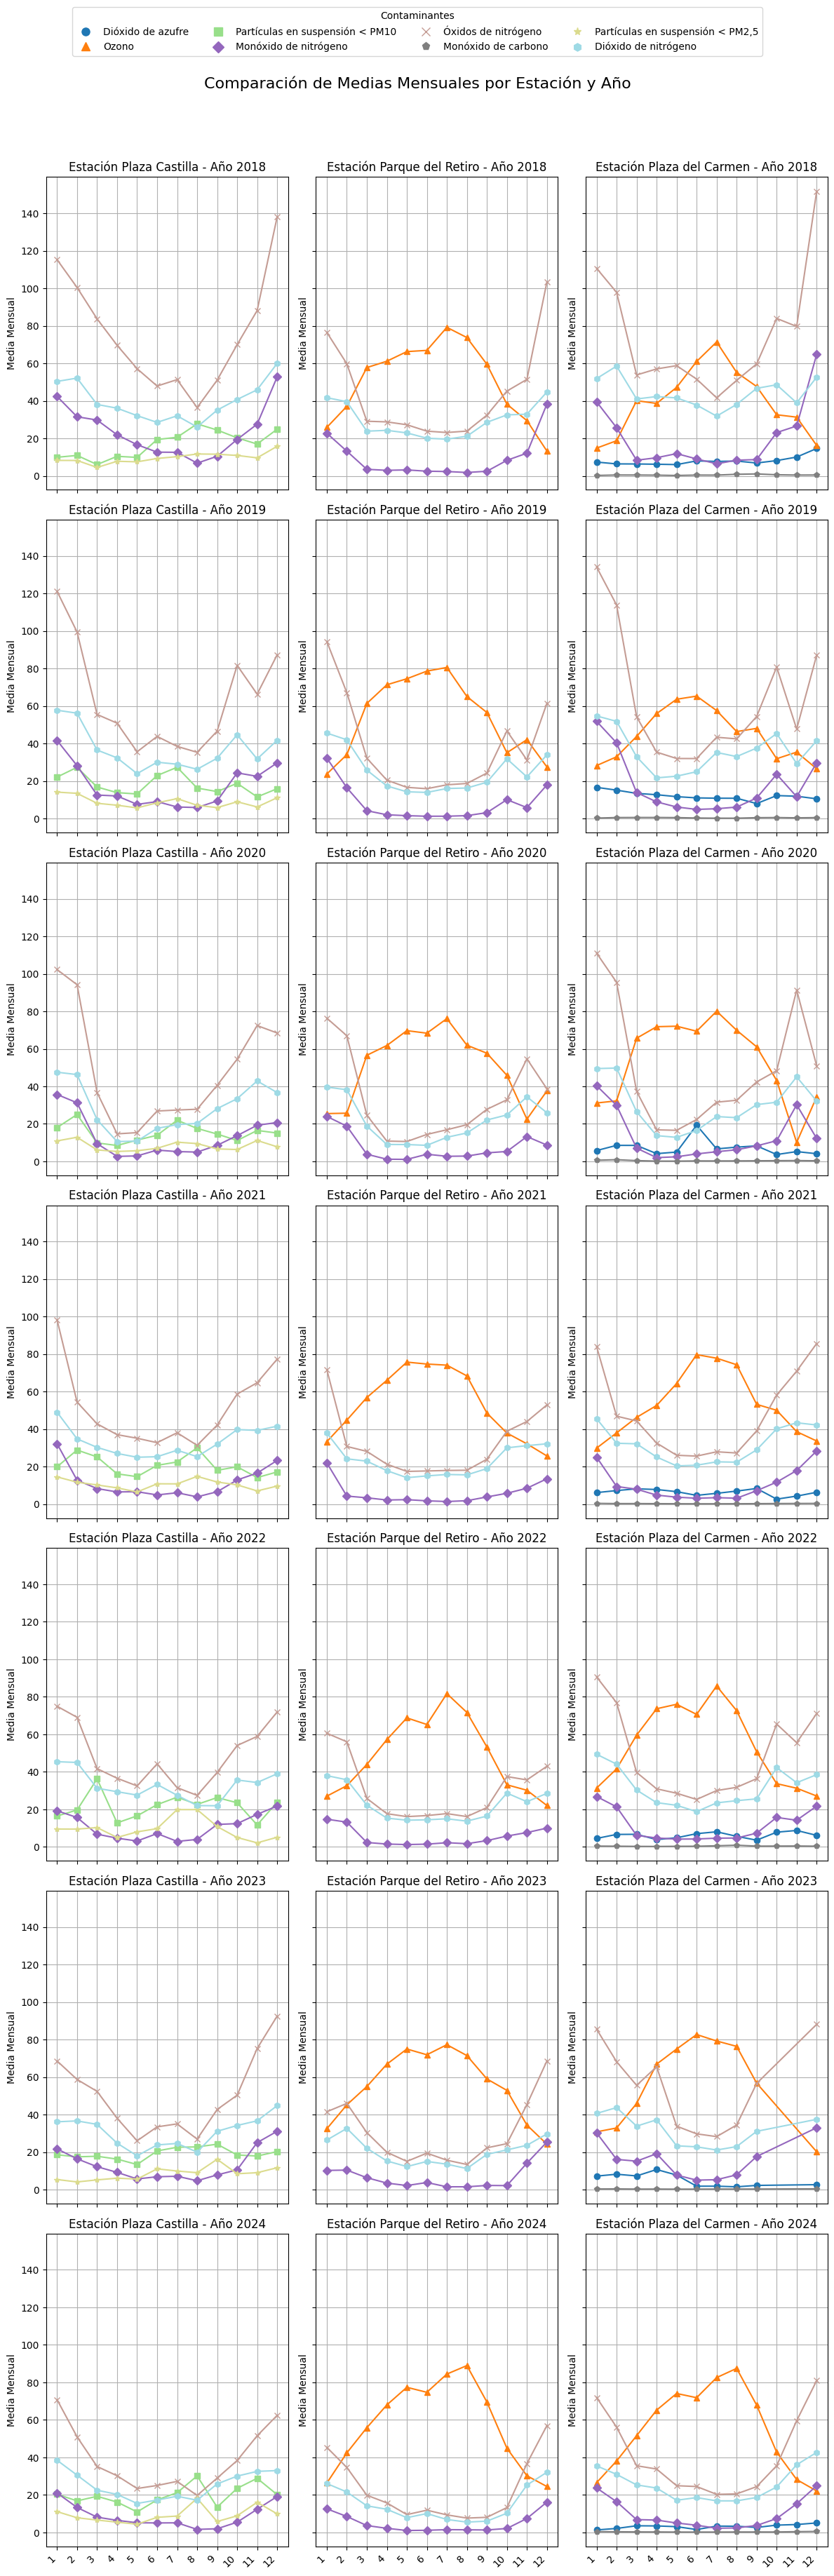

In [8]:
# Creamos un diccionario con un color para cada contaminante
cmap = plt.get_cmap("tab20", len(contaminantes))
colores_dict = {cont: cmap(i) for i, cont in enumerate(contaminantes)}

# Crear una lista de marcadores suficientemente variada para los contaminantes
# y hacemos un diccionario con un marcador para cada contaminante
# para facilitar la visualización
marcadores_unicos = ['o', '^', 's', 'D', 'x', 'p', '*', 'h', '+', 'X', '|', '_', 'v', '<', '4']
marcadores_dict = {cont: marcadores_unicos[i % len(marcadores_unicos)] for i, cont in enumerate(contaminantes)}
# Obtener años únicos
años_unicos = df_mensual["año"].unique().to_list()
num_años = len(años_unicos)


# Definir el número de columnas (una por estación)
num_cols = 3  
num_rows = num_años  # Una fila por año

fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 5 * num_rows), sharex=True, sharey=True)

# Convertir los ejes en lista para acceder más fácilmente
axes = axes.flatten().tolist()

# Iterar sobre cada año
for i, año in enumerate(años_unicos):
    df_año = df_mensual.filter(pl.col("año") == año)

    for j, estacion in enumerate(estaciones):  
        df_estacion = df_año.filter(pl.col("estacion") == estacion).sort("mes")

        ax = axes[i * num_cols + j]  # Acceder a la posición correcta en el grid
        
        # Graficar cada contaminante
        for contaminante in contaminantes:
            df_contaminante = df_estacion.filter(pl.col("contaminante") == contaminante)
            if df_contaminante.height > 0:
                ax.plot(df_contaminante["mes"], df_contaminante["media_mensual"], 
                        marker=marcadores_dict[contaminante], color=colores_dict[contaminante], label=contaminante)

        # Configuración del gráfico
        ax.set_title(f"Estación {estacion} - Año {año}")
        ax.set_ylabel("Media Mensual")
        ax.set_xticks(df_contaminante["mes"].to_list())
        ax.set_xticklabels(df_contaminante["mes"], rotation=45, ha="right")
        ax.grid(True)
# Creamos los elementos de la leyenda
handles, labels = [], [] # Listas para almacenar iconos y etiquetas
for contaminante in contaminantes:
    # Añadimos un icono que es un marcador con el color correspondiente para cada contaminante
    handles.append(plt.Line2D([0], [0], marker=marcadores_dict[contaminante], color=colores_dict[contaminante], linestyle='None', markersize=8))
    labels.append(contaminante)

# Agregar la leyenda única con los colores y marcadores correctos
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.05), title="Contaminantes", frameon=True, ncol=4, fontsize=10)
# Ajustes finales
fig.suptitle("Comparación de Medias Mensuales por Estación y Año", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

A primera vista podemos ver que se miden distintos contaminantes en cada estación, aunque comparten los compuestos de nitrógeno (monóxido, dióxido y óxidos), que se miden en todas las estaciones. La estación de tráfico mide los dos tipos de partículas en suspensión, mientras que la de fondo mide ozono, dióxido de azufe y monóxido de carbono. La del Parque del Retiro solo mide ozono, además de los compuestos de nitrógeno.
A lo largo del año se mantiene las tendencias de aumento de compuestos de nitrógeno en los meses fríos y aumento del ozono en los cálidos.
Para comparar años sacamos los valores numéricos.

In [ ]:
df_castilla = df_mensual.filter(pl.col("estacion") == "Plaza Castilla")

tabla_cambios = df_castilla.group_by(["año", "contaminante"]).agg(
    pl.col("media_mensual").mean().round(2).alias("media_anual")
).sort(["contaminante", "año"])

tabla_cambios

año,contaminante,media_anual
i32,str,f64
2018,"""Dióxido de nitrógeno""",39.74
2019,"""Dióxido de nitrógeno""",36.9
2020,"""Dióxido de nitrógeno""",28.01
2021,"""Dióxido de nitrógeno""",33.19
2022,"""Dióxido de nitrógeno""",32.73
2023,"""Dióxido de nitrógeno""",30.51
2024,"""Dióxido de nitrógeno""",25.23
2018,"""Monóxido de nitrógeno""",23.69
2019,"""Monóxido de nitrógeno""",17.46


La estación de Plaza Castilla presenta una reducción en las medias anuales de los contaminantes de nitrógeno, que son los debidos principalmente al tráfico y las combustiones, por lo que se puede ejercer cierto control con normativas y regulaciones. Sin embargo, las partículas son más variables, ya que, aunque se producen partículas en las combustiones o en obras, la mayor parte son debidas a polen o polvo, que dependen más de la meteorología, como por ejemplo el polvo del desierto de Sáhara.

In [ ]:
df_carmen = df_mensual.filter(pl.col("estacion") == "Plaza del Carmen")

tabla_cambios = df_carmen.group_by(["año", "contaminante"]).agg(
    pl.col("media_mensual").mean().round(2).alias("media_anual")
).sort(["contaminante", "año"])

tabla_cambios

año,contaminante,media_anual
i32,str,f64
2018,"""Dióxido de azufre""",7.96
2019,"""Dióxido de azufre""",12.12
2020,"""Dióxido de azufre""",7.24
2021,"""Dióxido de azufre""",6.27
2022,"""Dióxido de azufre""",6.17
2023,"""Dióxido de azufre""",5.18
2024,"""Dióxido de azufre""",3.16
2018,"""Dióxido de nitrógeno""",44.14
2019,"""Dióxido de nitrógeno""",35.93


La estación de Plaza del Carmen también presenta una reducción en las medias anuales de los compuestos de nitrógeno, aunque menos gradual que la estación de tráfico; también se han reducido los valores de monóxido de carbono y dióxido de azufre, sin embargo, el ozono ha aumentado significativamente.

También vamos a comparar los valores entre estaciones en los 3 contaminantes que miden todas: Óxidos de nitrógeno, Dióxido de nitrógeno y Monóxido de nitrógeno

In [9]:
# Filtro para estaciones
estaciones_filtrar = ["Plaza Castilla", "Plaza del Carmen", "Parque del Retiro"]
# Filtro para contaminantes
contaminantes_filtrar = ["Óxidos de nitrógeno", "Dióxido de nitrógeno", "Monóxido de nitrógeno"]
# Filtramos el df y calculamos la media anual
df_filtrado = df_mensual.filter(
    pl.col("estacion").is_in(estaciones_filtrar) & 
    pl.col("contaminante").is_in(contaminantes_filtrar)
).group_by(["año", "contaminante", "estacion"]).agg(
    pl.col("media_mensual").mean().round(2).alias("media_anual")
).sort(["contaminante", "año"])

# Pasamos a formato ancho para ver valores en paralelo
df_pivotado = df_filtrado.pivot(
    values="media_anual", 
    index=["año", "contaminante"], 
    on="estacion")

df_pivotado

año,contaminante,Plaza del Carmen,Plaza Castilla,Parque del Retiro
i32,str,f64,f64,f64
2018,"""Dióxido de nitrógeno""",44.14,39.74,29.3
2019,"""Dióxido de nitrógeno""",35.93,36.9,24.92
2020,"""Dióxido de nitrógeno""",29.59,28.01,21.54
2021,"""Dióxido de nitrógeno""",31.35,33.19,23.0
2022,"""Dióxido de nitrógeno""",31.45,32.73,22.23
2023,"""Dióxido de nitrógeno""",31.47,30.51,20.2
2024,"""Dióxido de nitrógeno""",25.57,25.23,14.87
2018,"""Monóxido de nitrógeno""",20.16,23.69,9.44
2019,"""Monóxido de nitrógeno""",17.81,17.46,8.16


En general no parece haber cambios muy grandes entre los valores de las estaciones de tráfico y fondo, sin embargo en la del Retiro se miden valores menores en todos los años y contaminantes.
Si nos centramos en el 2020, año del confinamiento, podemos ver una bajada respecto a 2019 y 2021 en el dióxido de nitrógeno, por lo que se puede pensar que es el más afectado por el tráfico. Vamos a representar las medias anuales de estos 3 contaminantes por estación para verlos mejor

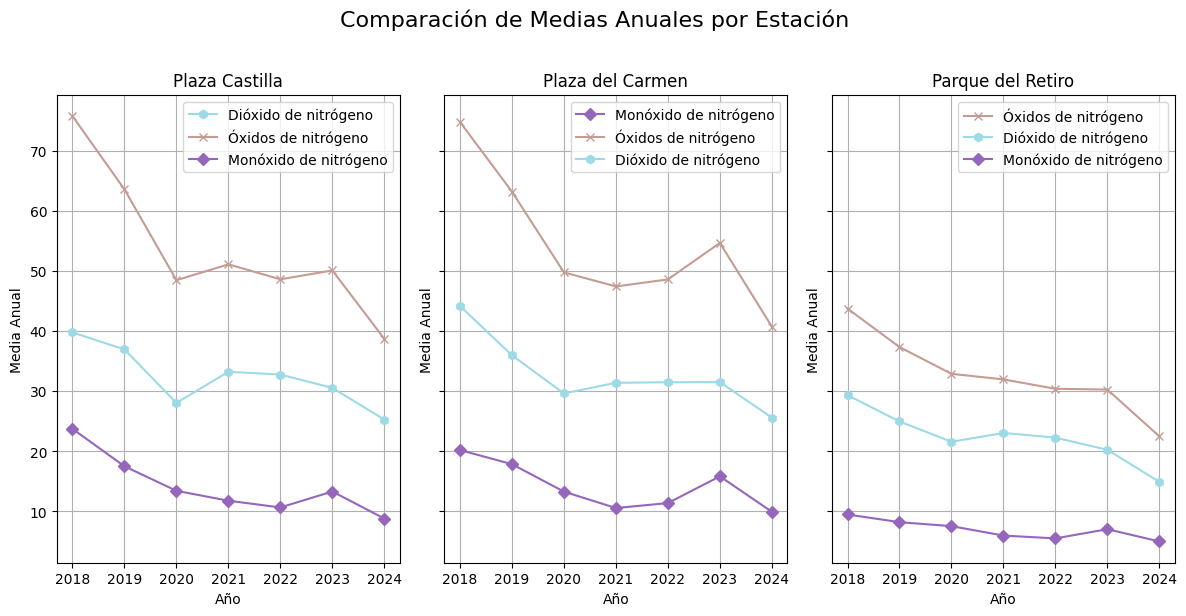

In [35]:
# Creamos un diccionario con un color para cada contaminante
cmap = plt.get_cmap("tab20", len(contaminantes))
colores_dict = {cont: cmap(i) for i, cont in enumerate(contaminantes)}


# Crear la figura con dos subgráficos en paralelo con 1 filas y 2 columnas
fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharex=True, sharey=True)


# Iteramos sobre cada estación
for i, estacion in enumerate(estaciones_filtrar):
    df_estacion = df_pivotado.select(["año", "contaminante", estacion])

    ax = axes[i]
    for contaminante in df_estacion["contaminante"].unique():
        df_contaminante = df_estacion.filter(pl.col("contaminante") == contaminante)
        ax.plot(df_contaminante["año"], df_contaminante[estacion], 
                marker=marcadores_dict[contaminante], color=colores_dict[contaminante], label=contaminante)

    ax.set_title(f"{estacion}")
    ax.set_ylabel("Media Anual")
    ax.set_xlabel("Año")
    ax.grid(True)
    ax.legend()

# Ajustes finales
fig.suptitle("Comparación de Medias Anuales por Estación", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Se puede ver la disminución del valor de dióxido de nitrógeno en 2020, y que en 2023 hay un pico de óxidos y de monóxido de nitrógeno. En general los valores son similares en las estaciones de Plaza Castilla y Plaza del Carmen, mientras que en la de Parque del Retiro son menores y los picos de 2023 son bastante menos notables.

Para ver el efecto del confinamiento, vamos a representar las medias diarias de los primeros 6 meses de 2020 para las 3 estaciones.

In [11]:
conexion = os.getenv("conexion_bbdd")
madrid_20 = feda.obtener_datos_madrid(conexion, 2020, 2020, "Madrid")

Conexión establecida y consulta de prueba exitosa.


In [12]:
madrid_20 = madrid_20.with_columns(pl.col("valor").cast(pl.Float64))

In [50]:
df_2020 = (madrid_20.with_columns(
        pl.col("hora_medida").dt.date().alias("fecha"),
        pl.col("hora_medida").dt.month().alias("mes"))
            .group_by(["estacion", "contaminante", "mes", "fecha"])  
            .agg(pl.col("valor").mean().round(2).alias("media_diaria"))  
            .sort(["estacion", "contaminante", "mes","fecha"])
                )
meses_filtro = [2, 3, 4, 5, 6]
df_confinamiento = df_2020.filter(pl.col("mes").is_in(meses_filtro) & pl.col("estacion").is_in(["Plaza Castilla", "Plaza del Carmen", "Parque del Retiro", "Plaza de España"]))
#df_confinamiento

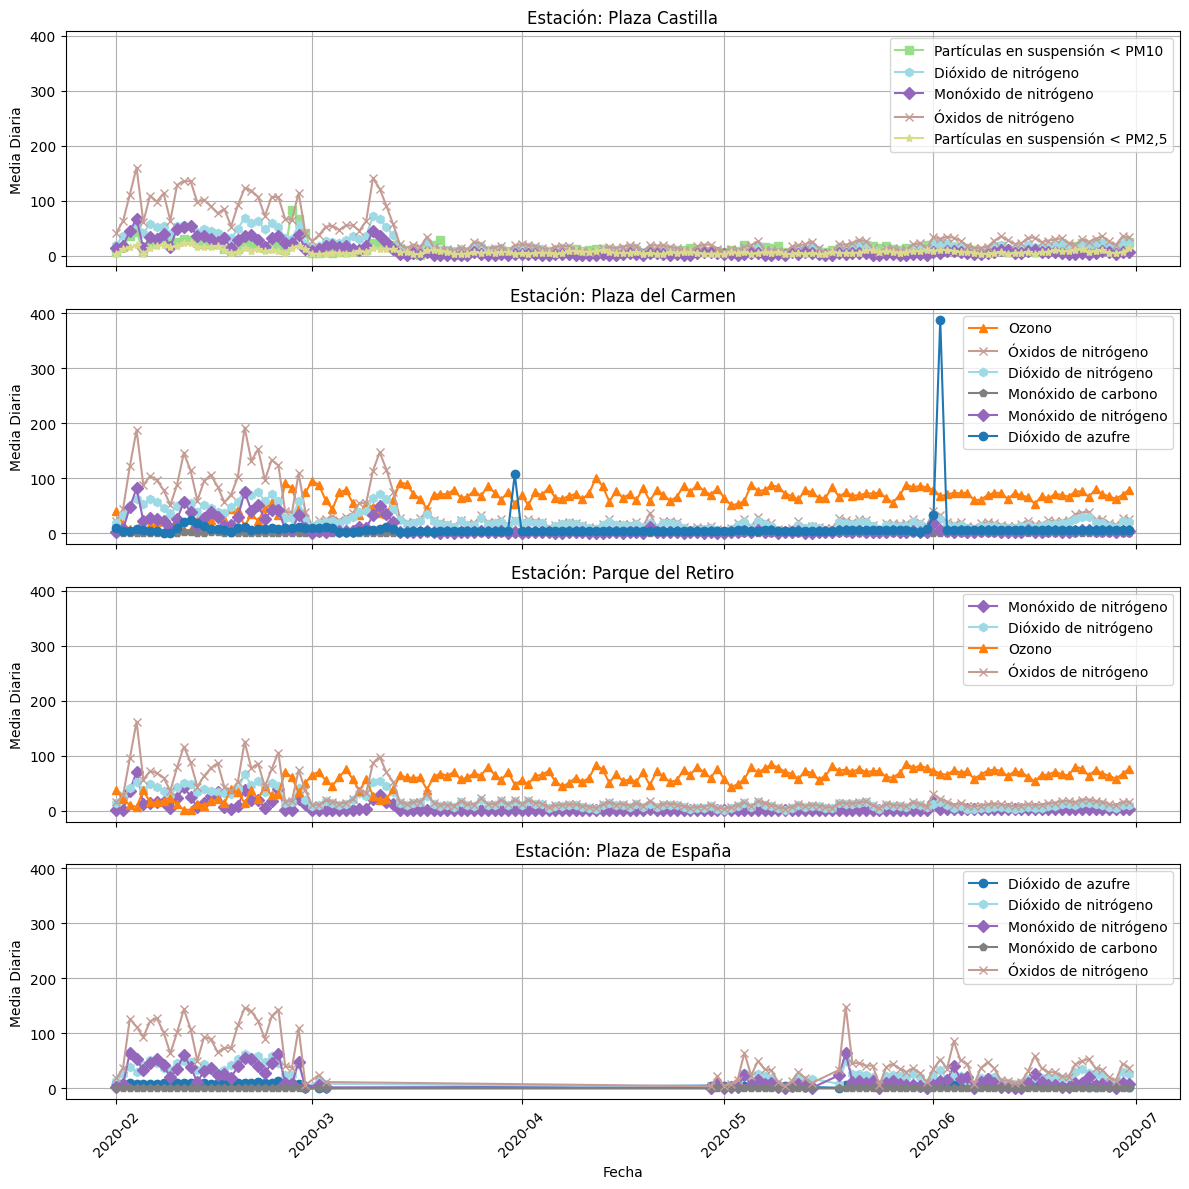

In [52]:
# Creamos un diccionario con un color para cada contaminante
cmap = plt.get_cmap("tab20", len(contaminantes))
colores_dict = {cont: cmap(i) for i, cont in enumerate(contaminantes)}
# Crear la figura con 3 subgráficos (una columna, tres filas)
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True, sharey=True)

# Iterar sobre las estaciones y asignar cada gráfico a un eje
for i, estacion in enumerate(["Plaza Castilla", "Plaza del Carmen", "Parque del Retiro", "Plaza de España"]):
    df_estacion = df_confinamiento.filter(pl.col("estacion") == estacion)

    ax = axes[i]  # Eje correspondiente a cada estación
    for contaminante in df_estacion["contaminante"].unique():
        df_contaminante = df_estacion.filter(pl.col("contaminante") == contaminante)
        ax.plot(df_contaminante["fecha"], df_contaminante["media_diaria"], 
                marker=marcadores_dict[contaminante], color=colores_dict[contaminante], label=contaminante)

    # Configuración del subgráfico
    ax.set_title(f"Estación: {estacion}")
    ax.set_ylabel("Media Diaria")
    ax.grid(True)
    ax.legend()

# Ajustes finales
plt.xticks(rotation=45)
plt.xlabel("Fecha")
plt.tight_layout()
plt.show()

Resulta evidente que, desde mediados de marzo (cuando comenzó el confinamiento), los valores de contaminación derivada del tráfico disminuyen, incluso llegan a 0 como en la estación de Plaza de España.